<table style="width:100%; font-size:11pt; border-collapse:collapse">
    <tr>
        <td colspan="2"
            style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   text-align:center;
                   font-weight:bold;
                   padding:8px;">
            Universidad de Oriente
        </td>
    </tr>
    <tr>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
                            Machine Learning
        </td>
        <td style="border: 1px #0098cd solid;
                   background-color:#E6F4F9;
                   color:#0098CD;
                   width:50%;
                   text-align:center;
                   padding:6px;">
            Clase 09 - Ejemplo 1 - Regresión lineal múltiple
        </td>
    </tr>
    <tr>
 

</table>

## Ejemplo 1

La base de datos contiene 20,000 registros estructurados de estudiantes que recopilan información relacionada con hábitos de estudio, patrones de uso digital, indicadores de bienestar, métricas de productividad y resultados académicos.

El conjunto de datos incluye variables como horas diarias de estudio, uso de teléfono inteligente y redes sociales, duración del sueño, niveles de estrés, puntuaciones de concentración, puntuaciones de productividad, asistencia y calificaciones finales. Permite un análisis integral de cómo diferentes factores conductuales y de estilo de vida influyen de manera conjunta en la productividad y el éxito académico de los estudiantes.

a) Describir el conjunto de datos.

b) Dividir el conjunto de datos en 25% de observaciones para la validación y el 75% restante pata el entrenamiento y obtener el modelo de regresión lineal múltiple.

c) Determinar cuales variables no son significativas para el modelo.

d) Obtener el $R^2$ y el error cuadrático medio del modelo de regresión.

e) Evaluar la posible multicolinealidad entre las variables predictoras mediante el Factor de Inflación de la Varianza (VIF) y los autovalores de la matriz de correlación.

f) Realizar un gráfico de dispersión de los valores reales vs los valores predichos.

g) Deteminar el puntaje de productividad esperado tomando como valor la mediana de todas las variables predictoras

In [1]:
#Cargar librerias
import pandas as pd
import os
import tarfile
import urllib.request
import numpy as np
from pandas.core.common import flatten
from plotnine import *
from array import *
import seaborn as sns
import scipy.stats as stats
import math
import matplotlib as mpl
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms

In [2]:
#Cargar la base de datos
datos = pd.read_csv("student_productivity.csv")

Para describir el conjunto de datos se realiza un análisis exploratorio inicial utilizando los métodos .info() y .describe(), junto con histogramas y diagramas de caja y bigote. Mediante .info() se identifica la estructura general de la base de datos, el número de registros, el tipo de datos de cada variable y la posible presencia de valores nulos.

Con .describe() se obtienen medidas estadísticas descriptivas como la media, desviación estándar, valores mínimos y máximos, así como los cuartiles, lo que permite conocer la tendencia central y la dispersión de las variables numéricas.

In [3]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 18 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             20000 non-null  int64  
 1   age                    20000 non-null  int64  
 2   gender                 20000 non-null  object 
 3   study_hours_per_day    20000 non-null  float64
 4   sleep_hours            20000 non-null  float64
 5   phone_usage_hours      20000 non-null  float64
 6   social_media_hours     20000 non-null  float64
 7   youtube_hours          20000 non-null  float64
 8   gaming_hours           20000 non-null  float64
 9   breaks_per_day         20000 non-null  int64  
 10  coffee_intake_mg       20000 non-null  int64  
 11  exercise_minutes       20000 non-null  int64  
 12  assignments_completed  20000 non-null  int64  
 13  attendance_percentage  20000 non-null  float64
 14  stress_level           20000 non-null  int64  
 15  fo

In [4]:
datos.describe()

,student_id,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
count,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,10000.500000,23.00745,5.254562,6.517799,6.250479,4.003655,2.990177,2.988339,7.542400,249.654550,59.648050,9.494100,69.947435,5.478750,64.444350,70.266409,50.180419
std,5773.647028,3.75489,2.742876,2.029784,3.313082,2.305154,1.729815,1.732803,4.016231,143.711231,34.611751,5.801469,17.397431,2.866943,20.176114,17.282277,16.086666
min,1.000000,17.00000,0.500000,3.000000,0.500000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,40.000000,1.000000,30.000000,40.000000,0.000000
25%,5000.750000,20.00000,2.900000,4.770000,3.380000,2.000000,1.487500,1.490000,4.000000,125.000000,30.000000,4.000000,54.810000,3.000000,47.000000,55.460000,38.700000
50%,10000.500000,23.00000,5.250000,6.510000,6.240000,4.010000,2.980000,2.970000,8.000000,249.000000,60.000000,9.000000,69.985000,5.000000,65.000000,70.315000,50.235000
75%,15000.250000,26.00000,7.640000,8.310000,9.102500,5.970000,4.480000,4.490000,11.000000,373.000000,90.000000,15.000000,85.050000,8.000000,82.000000,85.340000,61.782500
max,20000.000000,29.00000,10.000000,10.000000,12.000000,8.000000,6.000000,6.000000,14.000000,499.000000,119.000000,19.000000,100.000000,10.000000,99.000000,99.990000,100.000000


In [5]:
#Crear matriz de correlación
corr = datos.drop(["gender","student_id"], axis=1).corr()
corr.style.background_gradient()

,age,study_hours_per_day,sleep_hours,phone_usage_hours,social_media_hours,youtube_hours,gaming_hours,breaks_per_day,coffee_intake_mg,exercise_minutes,assignments_completed,attendance_percentage,stress_level,focus_score,final_grade,productivity_score
age,1.000000,-0.005029,0.010650,0.009090,0.003258,0.013934,0.001777,-0.006727,0.006629,0.001646,-0.003458,-0.006531,-0.002612,-0.004130,-0.000857,-0.005423
study_hours_per_day,-0.005029,1.000000,0.001670,0.011539,0.004888,-0.002238,-0.002104,-0.010371,0.004788,0.004380,0.005643,-0.008083,0.001781,0.004536,-0.012208,0.732777
sleep_hours,0.010650,0.001670,1.000000,0.000016,-0.005939,0.004920,-0.003666,-0.000677,0.000882,0.006526,0.000944,0.003433,0.000020,-0.003241,0.010543,0.340902
phone_usage_hours,0.009090,0.011539,0.000016,1.000000,0.004030,0.004108,-0.007497,-0.005431,-0.000064,-0.003186,0.006213,-0.002986,0.006138,-0.000206,-0.012136,-0.326650
social_media_hours,0.003258,0.004888,-0.005939,0.004030,1.000000,-0.005172,0.006406,-0.004077,-0.003837,-0.006226,0.003418,0.009388,0.000355,-0.001285,-0.000117,0.001285
youtube_hours,0.013934,-0.002238,0.004920,0.004108,-0.005172,1.000000,0.005033,-0.012604,0.006495,0.002128,0.011149,0.005766,0.007351,0.003745,0.001579,-0.000224
gaming_hours,0.001777,-0.002104,-0.003666,-0.007497,0.006406,0.005033,1.000000,0.005545,-0.010977,-0.000823,0.000179,0.010962,0.001791,-0.001462,0.002544,0.000685
breaks_per_day,-0.006727,-0.010371,-0.000677,-0.005431,-0.004077,-0.012604,0.005545,1.000000,-0.000057,-0.015312,0.010554,0.003253,0.002395,0.000269,-0.003690,-0.005836
coffee_intake_mg,0.006629,0.004788,0.000882,-0.000064,-0.003837,0.006495,-0.010977,-0.000057,1.000000,0.011384,0.007968,0.003035,-0.008850,0.010121,0.015326,0.010190
exercise_minutes,0.001646,0.004380,0.006526,-0.003186,-0.006226,0.002128,-0.000823,-0.015312,0.011384,1.000000,-0.003826,0.004321,0.009474,-0.006284,-0.002677,0.002892


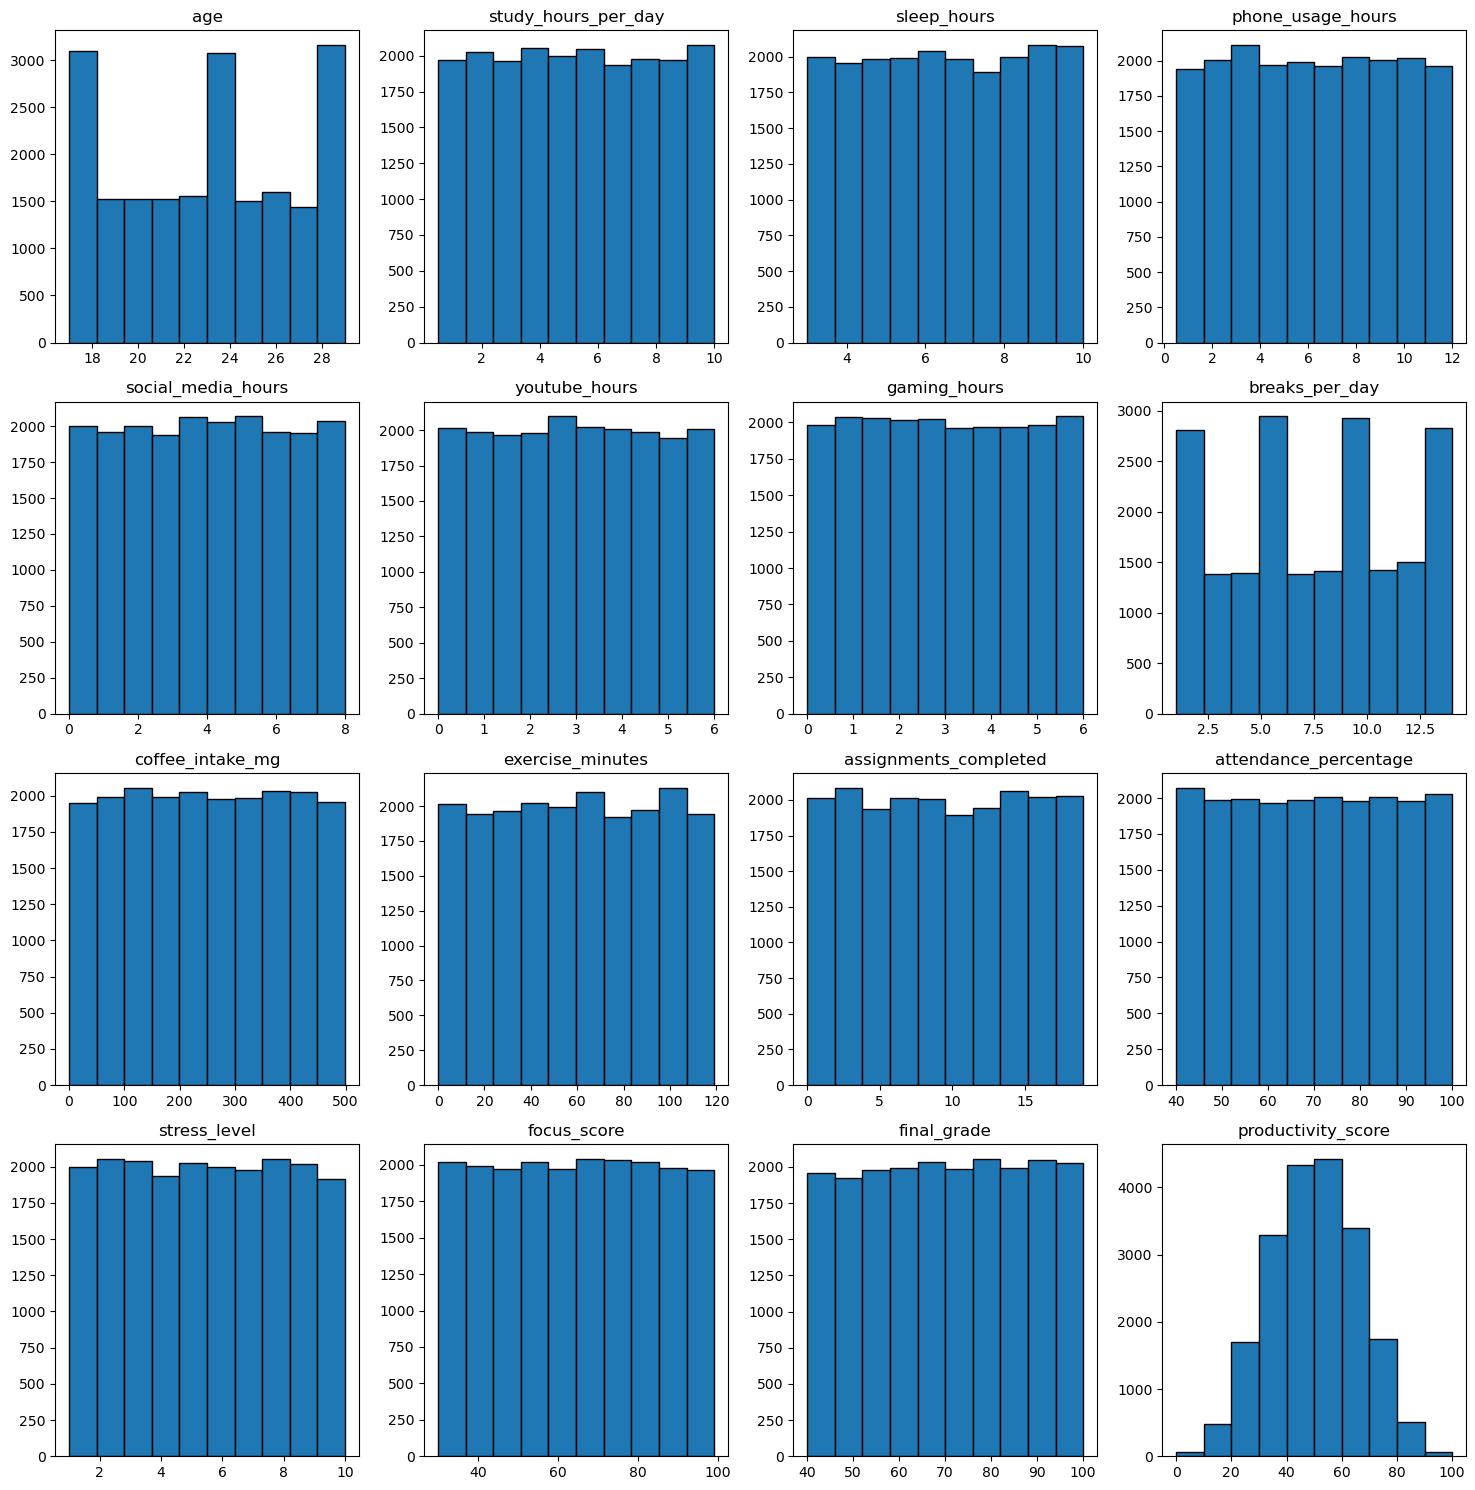

In [6]:
vars_num = datos.select_dtypes(include='number').columns.drop(["student_id"]).tolist()

plt.figure(figsize=(15,15))

for i, var in enumerate(vars_num):
    plt.subplot(4, 4, i+1)
    plt.hist(datos[var], edgecolor="black",bins=10)
    plt.title(var)

plt.tight_layout()
plt.show()

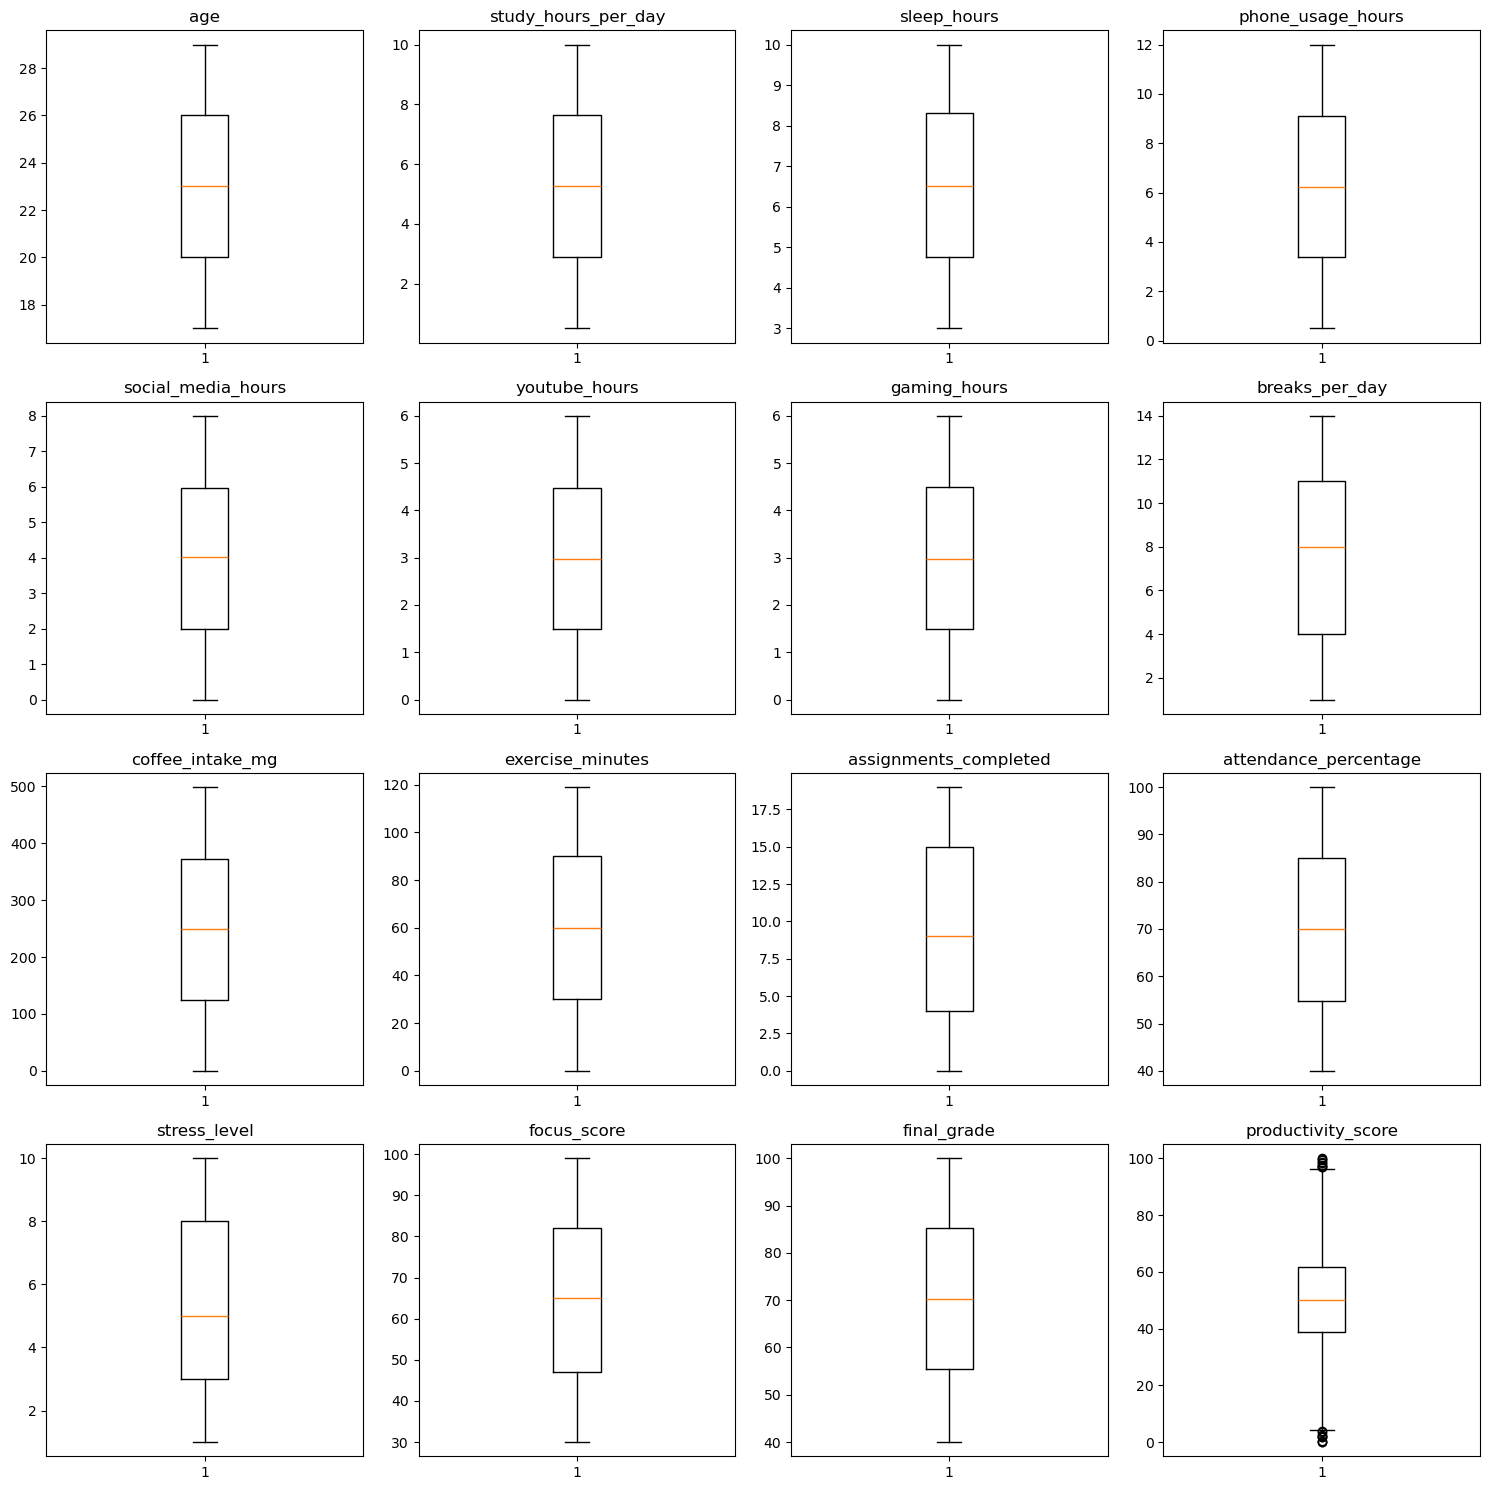

In [7]:
#Diagramas de caja y bigote
plt.figure(figsize=(15,15))

for i, var in enumerate(vars_num):
    plt.subplot(4, 4, i+1)
    plt.boxplot(datos[var])
    plt.title(var)

plt.tight_layout()
plt.show()

A partir del método .info() se observa que el conjunto de datos está compuesto por 20,000 registros y 18 variables, incluyendo variables numéricas y una variable categórica  Asimismo, todas las variables presentan 20,000 valores no nulos, lo que indica que no existen datos faltantes en el conjunto, por lo que no es necesario realizar un procesamiento previo relacionado con la imputación o eliminación de valores ausentes.

Por otro lado, mediante los diagramas de caja y bigote se identifica la presencia de un dato atípico en la variable productivity_score, lo cual sugiere la existencia de un valor extremo que se aleja del comportamiento general de los datos. Este tipo de observaciones resulta importante, ya que los valores atípicos pueden influir en el análisis estadístico y en el desempeño de los modelos predictivos.

b)  Se realiza la selección de las variables numéricas del conjunto de datos, excluyendo la variable identificadora student_id y la variable objetivo productivity_score, con el fin de definir las variables independientes del modelo. De esta forma, se construye la matriz de características $X$ a partir de las variables explicativas, mientras que la variable productivity_score se define como la variable dependiente 

Posteriormente, se divide el conjunto de datos en subconjuntos de entrenamiento y prueba utilizando la función `train_test_split`. Se asigna el 75% de los datos para entrenamiento y el 25% para prueba, lo que permite entrenar el modelo y evaluar su desempeño en datos no utilizados durante el entrenamiento. Además, se establece una semilla aleatoria (`random_state=2026`) para garantizar la reproducibilidad de los resultados.

In [8]:
from sklearn.model_selection import train_test_split

vars_num = datos.select_dtypes(include='number').columns.drop(["student_id","productivity_score"]).tolist()

x_independientes = datos[vars_num]
y_dependientes = datos["productivity_score"].copy()

#Obtenemos las muestras de entrenamiento y test por medio de la función train_test_split
X_train, X_test, y_train, y_test= train_test_split(x_independientes, y_dependientes, test_size=0.25, random_state=2026)

In [9]:
#Crear la regresión
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [10]:
#Se muestra el intercepto
intercepto = lm.intercept_
print("El intercepto es que se tiene es %s" %intercepto)

El intercepto es que se tiene es -6.238752173705251


In [11]:
#Obtención de los coeficientes
coeficientes = lm.coef_

#Crear dataframe para mostrar los coeficientes
pd.DataFrame({"Variables": x_independientes.columns, "Coeficientes": coeficientes})

,Variables,Coeficientes
0,age,7.176968e-07
1,study_hours_per_day,4.316388e+00
2,sleep_hours,2.697745e+00
3,phone_usage_hours,-1.618631e+00
4,social_media_hours,-5.237254e-06
5,youtube_hours,1.198278e-05
6,gaming_hours,1.943411e-05
7,breaks_per_day,-3.408801e-06
8,coffee_intake_mg,1.358410e-07
9,exercise_minutes,8.412566e-07


c) Se construye un modelo de regresión lineal múltiple utilizando la librería `statsmodels`. En primer lugar, se añade el término independiente  a las variables explicativas mediante la función `add_constant`, lo cual es necesario para estimar correctamente el modelo.

Posteriormente, se ajusta el modelo de regresión lineal utilizando las variables de entrenamiento. Una vez ajustado el modelo, se obtiene un resumen estadístico mediante `summary()`, el cual proporciona información relevante como coeficientes estimados, errores estándar, valores t y valores p.

Este resumen se utiliza para evaluar la significancia estadística de cada variable independiente. En particular, los valores p permiten identificar aquellas variables que no son significativas dentro del modelo, es decir, aquellas cuyo valor p es mayor que un nivel de significancia comúnmente 0.05, indicando que no contribuyen de manera relevante a la explicación de la variable dependiente.

In [12]:
import statsmodels.api as sm
from scipy import stats

#Añadir el intercepto
X2 = sm.add_constant(X_train)
#Ajustar el modelo
est = sm.OLS(y_train, X2)

#Ver el ajuste
est2 = est.fit()
print(est2.summary())

                            OLS Regression Results                            
Dep. Variable:     productivity_score   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.138e+10
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        10:21:24   Log-Likelihood:                 66500.
No. Observations:               15000   AIC:                        -1.330e+05
Df Residuals:                   14984   BIC:                        -1.328e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    -6.23

Se observa que las variables age, social_media_hours, youtube_hours, gaming_hours, breaks_per_day, coffee_intake_mg, exercise_minutes, assignments_completed y final_grade presentan valores p mayores a 0.05, por lo que no son estadísticamente significativas dentro del modelo. Esto indica que dichas variables no contribuyen de manera relevante a explicar la variabilidad de la variable dependiente productivity_score en este ajuste del modelo.

d) Con el fin de cuantificar el modelo de regresión creado se determina el coeficiente de determinación $R^2$ y el error cuadrático medio.

In [15]:
#Obtener predicción para X_test
y_pred = lm.predict(X_test)

#Error cuadrático medio (MSE)
mse = mean_squared_error(y_test, y_pred)

#Coeficiente de determinación
r2 = r2_score(y_test, y_pred)

print("El error cuadrático medio que se tiene es %s" %mse)
print("El coeficiente de determinación del modelo es %.5f" %r2)

El error cuadrático medio que se tiene es 8.14043293737538e-06
El coeficiente de determinación del modelo es 1.00000


El modelo presenta un error cuadrático medio (MSE) de $8.140432937370768 \times 10^{-6}$, lo cual indica que, en promedio, las diferencias entre los valores reales y los valores predichos son extremadamente pequeñas, reflejando un ajuste muy preciso del modelo a los datos.

El coeficiente de determinación  indica que el modelo explica prácticamente el 100% de la variabilidad de la variable dependiente . Esto sugiere un ajuste casi perfecto. 

Se evalúa la presencia de multicolinealidad entre las variables independientes mediante el cálculo del Factor de Inflación de la Varianza (VIF). Para ello, se construye un DataFrame que contiene cada una de las variables explicativas y su correspondiente valor de VIF, utilizando la función `variance_inflation_factor` de la librería `statsmodels`.

El VIF permite medir cuánto se incrementa la varianza de los coeficientes estimados debido a la correlación entre las variables independientes. Valores de VIF cercanos a 1 indican baja correlación, mientras que valores superiores a 5 o 10 sugieren problemas de multicolinealidad que pueden afectar la estabilidad e interpretación del modelo. Este análisis es fundamental para validar la independencia entre las variables explicativas antes de ajustar el modelo de regresión.

In [16]:
# Variance Inflation Factor
from statsmodels.stats.outliers_influence import variance_inflation_factor

#Crear dataframe para aplicar VIF
VIF = pd.DataFrame()
VIF["variable"] = x_independientes.columns

#Aplicar el método
VIF["VIF"] = [variance_inflation_factor(x_independientes.values, i) for i in range(len(x_independientes.columns))]

VIF

,variable,VIF
0,age,26.843143
1,study_hours_per_day,4.523880
2,sleep_hours,10.434517
3,phone_usage_hours,4.432894
4,social_media_hours,3.923295
5,youtube_hours,3.911672
6,gaming_hours,3.884712
7,breaks_per_day,4.386410
8,coffee_intake_mg,3.939914
9,exercise_minutes,3.877844


A partir de los resultados obtenidos del Factor de Inflación de la Varianza (VIF), se observa que algunas variables presentan valores elevados, lo que indica la presencia de multicolinealidad en el modelo. En particular, las variables age , attendance_percentage , final_grade, sleep_hours y focus_score superan el umbral de 10, lo que sugiere una alta correlación con otras variables independientes y posibles problemas en la estimación de los coeficientes.

Por otro lado, el resto de variables presentan valores de VIF entre 3 y 5, lo cual indica una multicolinealidad moderada, pero generalmente aceptable dentro del modelo. En conjunto, estos resultados evidencian que existe dependencia lineal entre algunas variables explicativas, por lo que sería recomendable considerar la eliminación o transformación de aquellas con VIF elevado para mejorar la estabilidad e interpretación del modelo de regresión.

In [17]:
#Obtención de los autovalores de la matriz de correlación
corr_ind = x_independientes.corr()
av, v = np.linalg.eig(corr_ind)
AV = pd.DataFrame()
AV["Variable"] = x_independientes.columns
AV["Autovalor"] = av

AV

,Variable,Autovalor
0,age,0.957475
1,study_hours_per_day,1.040345
2,sleep_hours,1.038775
3,phone_usage_hours,0.963613
4,social_media_hours,0.968633
5,youtube_hours,1.029264
6,gaming_hours,1.019720
7,breaks_per_day,1.016257
8,coffee_intake_mg,1.012196
9,exercise_minutes,0.980772


A partir de los autovalores de la matriz de correlación, se observa que todos los valores son cercanos a 1 y ninguno se aproxima a 0. Esto indica que no existen combinaciones lineales fuertes entre las variables independientes, lo que sugiere que no hay problemas severos de multicolinealidad desde la perspectiva espectral.

En general, autovalores muy pequeños cercanos a 0 evidencian la presencia de dependencia lineal entre variables; sin embargo, en este caso los autovalores se mantienen en un rango aproximadamente entre 0.95 y 1.04. Por tanto, el conjunto de variables presenta una adecuada independencia lineal global, aunque algunos indicadores como el VIF pueden señalar relaciones particulares entre ciertas variables que conviene analizar de manera individual.

f) Se realiza el gráfico de dispersión para comparar los valores reales y los predichos, para corroborar los resultados del $R^2$. Al ser un $R^2$ cercano a uno, se espera que los datos se ajusten perfectamente a la recta identidad.

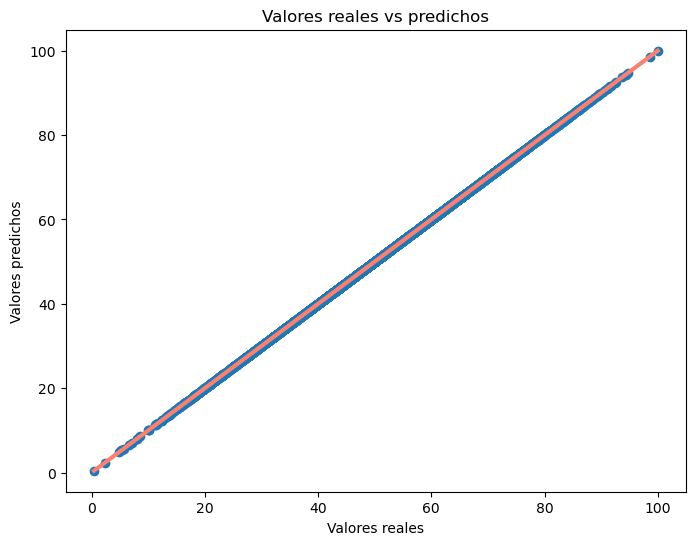

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.xlabel("Valores reales")
plt.ylabel("Valores predichos")
plt.title("Valores reales vs predichos")
plt.plot([min(y_test),max(y_test)],[min(y_test),max(y_test)],color='salmon',linewidth='3')
plt.show()

g) Para estimar el puntaje de productividad esperado, se consideran como valores de entrada las medianas de todas las variables predictoras. Esto implica construir un vector representativo del estudiante típico, donde cada variable independiente toma su valor mediano

In [19]:
#Se obtiene la mediana y se transforma en array
medianas =np.array(np.median(x_independientes,axis=0)) 

#Predicción
prediccion_medianas = lm.predict(medianas.reshape(1,-1))

print("El puntaje de productividad esperado es de %s" %prediccion_medianas)

El puntaje de productividad esperado es de [50.85922925]


C:\Users\gus_r\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names


### Fin